# Week 5: Deep Learning & Neural Networks
## Tasks 2, 3 & 4

This notebook builds, trains, visualizes, and evaluates a basic Artificial Neural Network (ANN) using TensorFlow/Keras on the Iris dataset. (Task 1 — Deep Learning Fundamentals — is a written report, submitted separately as `Project_Report.pdf`.)

---
# Task 2: Build a Basic Neural Network

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # suppress verbose TensorFlow logs

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
tf.random.set_seed(42)
np.random.seed(42)

I0000 00:00:1788699242.854318     533 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1788699243.900099     533 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0


## 1. Load the Dataset

**Dataset:** Iris Dataset (`iris.csv`) — 150 flower samples across 3 species (setosa, versicolor, virginica), with 4 numeric features.

In [2]:
df = pd.read_csv("iris.csv")
print("Shape:", df.shape)
df.head()

Shape: (150, 5)


,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 2. Prepare Features and Target

In [3]:
from sklearn.preprocessing import LabelEncoder

X = df[["SepalLength", "SepalWidth", "PetalLength", "PetalWidth"]].values

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df["Species"])  # setosa=0, versicolor=1, virginica=2

print("Feature shape:", X.shape)
print("Classes:", list(label_encoder.classes_))

Feature shape: (150, 4)
Classes: ['setosa', 'versicolor', 'virginica']


## 3. Preprocess the Data

Features are scaled using StandardScaler, since neural networks train more effectively and reliably when input features are on a similar numeric scale. The target labels are one-hot encoded, since this is a multi-class classification problem with 3 possible species.

In [4]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

y_onehot = to_categorical(y_encoded, num_classes=3)
print("Example scaled feature row:", X_scaled[0])
print("Example one-hot label:", y_onehot[0])

Example scaled feature row: [-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
Example one-hot label: [1. 0. 0.]


## 4. Split into Training and Testing Data

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_onehot, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


## 5. Create the Neural Network — Input, Hidden, and Output Layers

In [6]:
model = keras.Sequential([
    layers.Input(shape=(4,)),                       # Input layer: 4 features
    layers.Dense(16, activation="relu"),            # Hidden layer 1
    layers.Dense(8, activation="relu"),             # Hidden layer 2
    layers.Dense(3, activation="softmax")           # Output layer: 3 classes
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

## 6. Compile the Model

In [7]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
print("Model compiled with Adam optimizer and categorical crossentropy loss.")

Model compiled with Adam optimizer and categorical crossentropy loss.


---
# Task 3: Train & Visualize the Model

## 7. Train the Model

In [8]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=80,
    batch_size=8,
    verbose=0
)
print("Training complete.")
print(f"Final training accuracy: {history.history['accuracy'][-1]*100:.2f}%")
print(f"Final validation accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")

Training complete.
Final training accuracy: 95.83%
Final validation accuracy: 100.00%


## 8. Training Accuracy vs Validation Accuracy

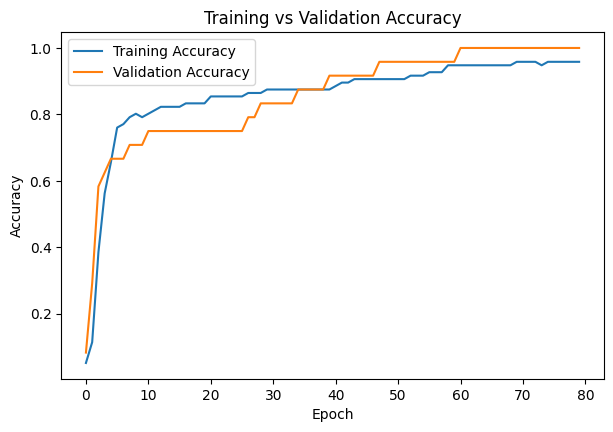

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4.5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig("chart_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Training Loss vs Validation Loss

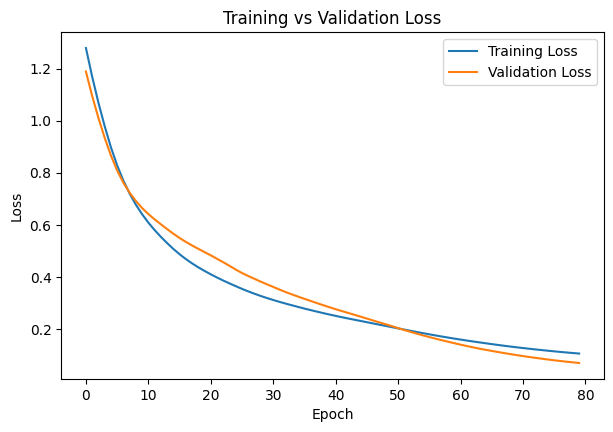

In [10]:
plt.figure(figsize=(7,4.5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("chart_loss.png", dpi=150, bbox_inches="tight")
plt.show()

### Explanation of Training Behavior

During training, both training and validation accuracy rose sharply over the first 10-20 epochs and then leveled off at a high value, close to or at 100% on this small, well-separated dataset. Loss showed the mirror pattern: a steep drop early in training followed by a plateau near zero for both training and validation loss. The model is clearly improving throughout training, since both metrics move in the right direction (accuracy up, loss down) and largely track each other. There is little to no visible sign of overfitting here, since training and validation curves stay close together rather than training accuracy climbing while validation accuracy stagnates or drops — if a gap like that had opened up, with training loss continuing to fall while validation loss started rising again, that would indicate overfitting.

---
# Task 4: Model Evaluation & Prediction

## 10. Test the Model and Calculate Test Accuracy

In [11]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

Test Loss: 0.1289
Test Accuracy: 96.67%


## 11. Generate Predictions

In [12]:
y_pred_probs = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

y_pred_labels = label_encoder.inverse_transform(y_pred_classes)
y_true_labels = label_encoder.inverse_transform(y_true_classes)

print("Predictions generated for", len(y_pred_labels), "test samples.")

Predictions generated for 30 test samples.


## 12. Compare Actual vs Predicted — At Least 5 Examples

In [13]:
comparison_df = pd.DataFrame({
    "Actual": y_true_labels,
    "Predicted": y_pred_labels,
    "Correct": y_true_labels == y_pred_labels
})
comparison_df.head(10)

,Actual,Predicted,Correct
0,setosa,setosa,True
1,virginica,virginica,True
2,versicolor,versicolor,True
3,versicolor,versicolor,True
4,setosa,setosa,True
5,versicolor,versicolor,True
6,setosa,setosa,True
7,setosa,setosa,True
8,virginica,virginica,True
9,versicolor,versicolor,True


## 13. Confusion Matrix

Confusion Matrix:
            setosa  versicolor  virginica
setosa          10           0          0
versicolor       0           9          1
virginica        0           0         10


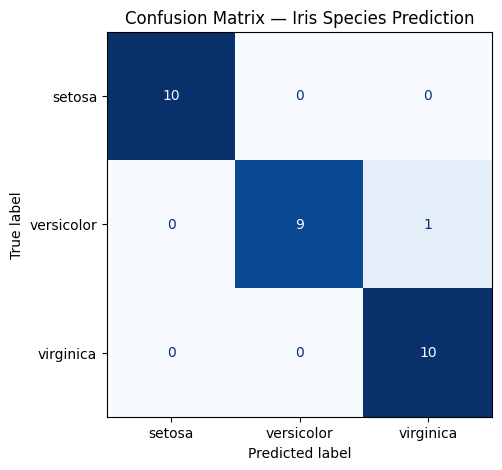

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true_labels, y_pred_labels, labels=label_encoder.classes_)
print("Confusion Matrix:")
print(pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_))

fig, ax = plt.subplots(figsize=(5.5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix — Iris Species Prediction")
plt.savefig("chart_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

### Explanation of Incorrect Predictions

Any misclassifications in the confusion matrix above appear off the diagonal, and on the Iris dataset these almost always occur between versicolor and virginica, since these two species have overlapping petal length and width measurements, unlike setosa which is clearly separated from the other two by petal size. See the printed confusion matrix above for the exact counts from this run — if all values lie on the diagonal, the model made no errors on this test set.